In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
import requests
from PIL import Image
from io import BytesIO
import matplotlib.pyplot as plt


In [ ]:
import os
import torch
import requests
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt

from transformers import AutoProcessor, AutoModelForZeroShotObjectDetection

import torch
from transformers import AutoProcessor, AutoModelForZeroShotObjectDetection
device = "cuda" if torch.cuda.is_available() else "cpu"

Grounding dino

In [ ]:
model_id = "IDEA-Research/grounding-dino-base"

processor = AutoProcessor.from_pretrained(model_id)
model = AutoModelForZeroShotObjectDetection.from_pretrained(model_id).to(device)
print(" GroundingDINO loaded")


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/457 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/933M [00:00<?, ?B/s]

 GroundingDINO loaded


In [ ]:
# 1. სქრიპტი weights-ის ჩამოტვირთვისთვის
!wget -O /content/sam_vit_h_4b8939.pth \
https://dl.fbaipublicfiles.com/segment_anything/sam_vit_h_4b8939.pth


--2026-01-08 10:31:06--  https://dl.fbaipublicfiles.com/segment_anything/sam_vit_h_4b8939.pth
Resolving dl.fbaipublicfiles.com (dl.fbaipublicfiles.com)... 108.156.144.46, 108.156.144.13, 108.156.144.61, ...
Connecting to dl.fbaipublicfiles.com (dl.fbaipublicfiles.com)|108.156.144.46|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 2564550879 (2.4G) [binary/octet-stream]
Saving to: ‘/content/sam_vit_h_4b8939.pth’

/content/sam_vit_h_ 100%[===================>]   2.39G   223MB/s    in 17s     

2026-01-08 10:31:23 (146 MB/s) - ‘/content/sam_vit_h_4b8939.pth’ saved [2564550879/2564550879]



(np.float64(-0.5), np.float64(2047.5), np.float64(2716.5), np.float64(-0.5))

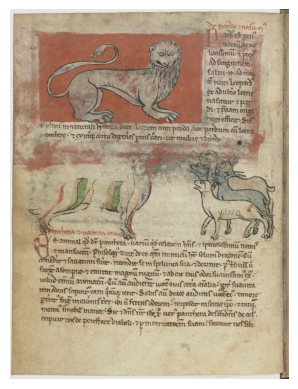

In [ ]:
import pandas as pd
import cv2
import matplotlib.pyplot as plt

# CSV
df = pd.read_csv("/content/drive/MyDrive/df_latin.csv")


row = df.iloc[28]

text_prompt = "animal"

# ფოტო
image_path = "/content/drive/MyDrive/2v.JPG"
image = cv2.imread(image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.imshow(image)
plt.axis("off")


In [ ]:
inputs = processor(
    images=image,
    text=text_prompt,
    return_tensors="pt"
).to(device)

with torch.no_grad():
    outputs = model(**inputs)



In [ ]:
results = processor.post_process_grounded_object_detection(
    outputs,
    threshold=0.3,
    target_sizes=[image.shape[:2]]
)[0]



In [ ]:
print(results.keys())


dict_keys(['scores', 'boxes', 'text_labels', 'labels'])


/usr/local/lib/python3.12/dist-packages/transformers/models/grounding_dino/processing_grounding_dino.py:93: FutureWarning: The key `labels` is will return integer ids in `GroundingDinoProcessor.post_process_grounded_object_detection` output since v4.51.0. Use `text_labels` instead to retrieve string object names.
  warnings.warn(self.message, FutureWarning)


(np.float64(-0.5), np.float64(2047.5), np.float64(2716.5), np.float64(-0.5))

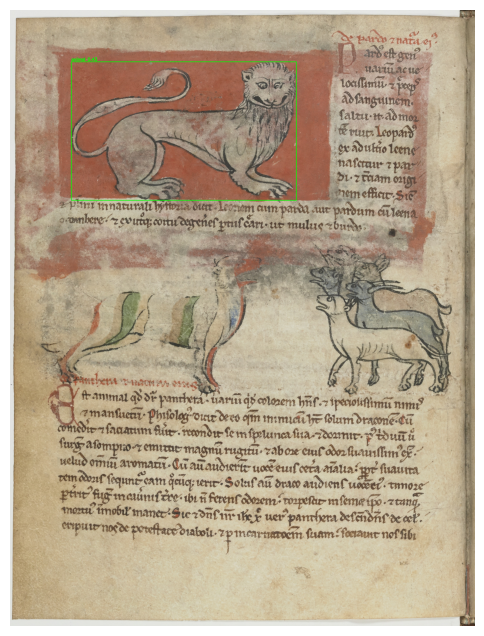

In [ ]:
import cv2
import matplotlib.pyplot as plt

img = image.copy()

for box, score, label in zip(
    results["boxes"],
    results["scores"],
    results["labels"]
):
    box = box.cpu().numpy().astype(int)
    x1, y1, x2, y2 = box

    cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 2)
    cv2.putText(
        img,
        f"{text_prompt} {score:.2f}",
        (x1, y1 - 5),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.6,
        (0, 255, 0),
        2
    )

plt.figure(figsize=(8,8))
plt.imshow(img)
plt.axis("off")


In [ ]:
df = pd.read_csv("/content/drive/MyDrive/df_latin.csv")
image_dir = "/content/drive/MyDrive/E"
import cv2

In [ ]:
results_all = []

for idx, row in df.iterrows():
    image_name = row["img_name"]
    image_path = os.path.join(image_dir, image_name)

    if not os.path.exists(image_path):
        print(f"not found: {image_name}")
        continue

    # load image
    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    # DINO inference with general 'animal, bird' prompt
    text_prompt = "animal, bird"  # მოდელს ვეუბნებით, რომ ყველა ცხოველი უნდა მოძებნოს

    inputs = processor(
        images=image,
        text=text_prompt,
        return_tensors="pt"
    ).to(device)

    with torch.no_grad():
        outputs = model(**inputs)

    results = processor.post_process_grounded_object_detection(
        outputs,
        threshold=0.3,
        target_sizes=[image.shape[:2]]
    )[0]

    # save results
    for box, score in zip(results["boxes"], results["scores"]):
        x1, y1, x2, y2 = box.cpu().numpy()
        results_all.append({
            "img_name": image_name,
            "mots_cles": text_prompt,
            "score": float(score),
            "x1": float(x1),
            "y1": float(y1),
            "x2": float(x2),
            "y2": float(y2)
        })

print(" DINO დასრულდა")

 DINO დასრულდა


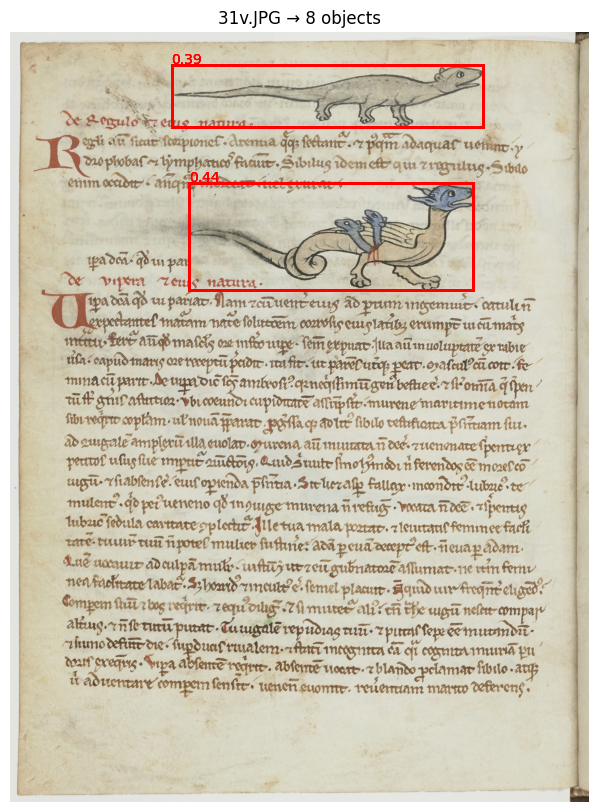

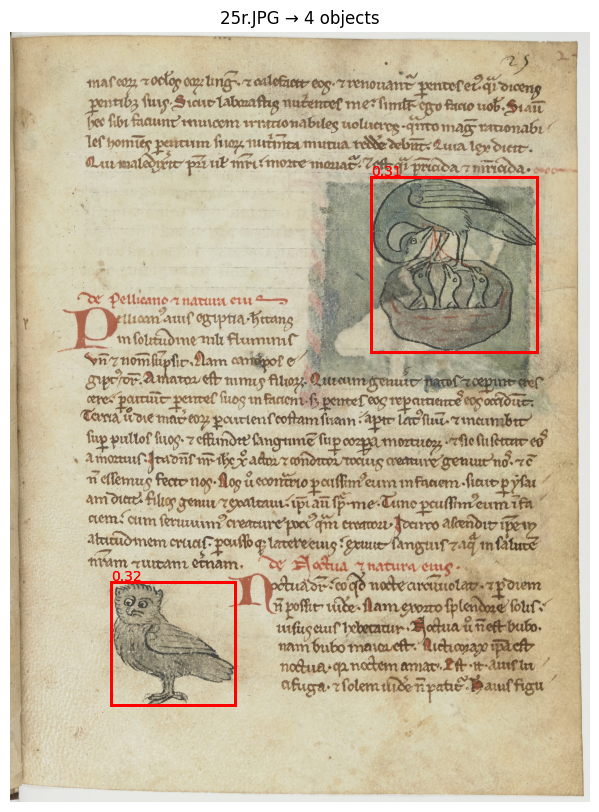

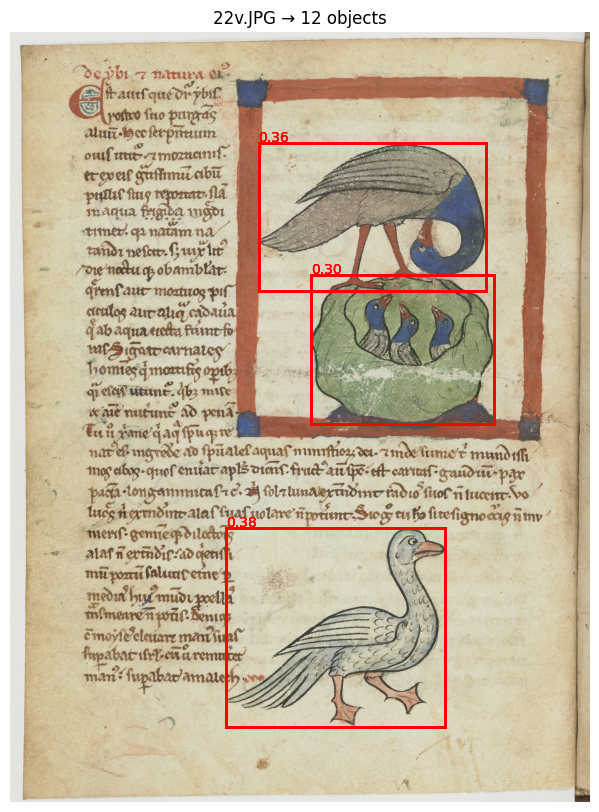

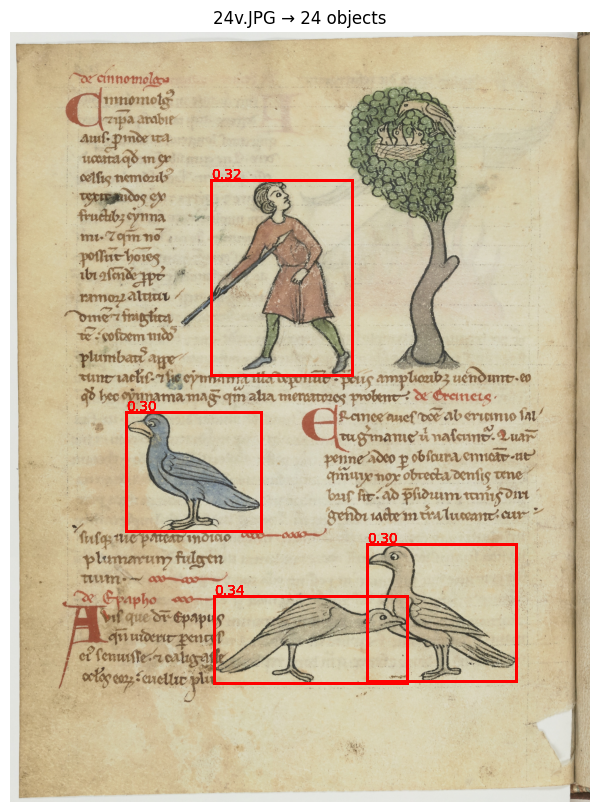

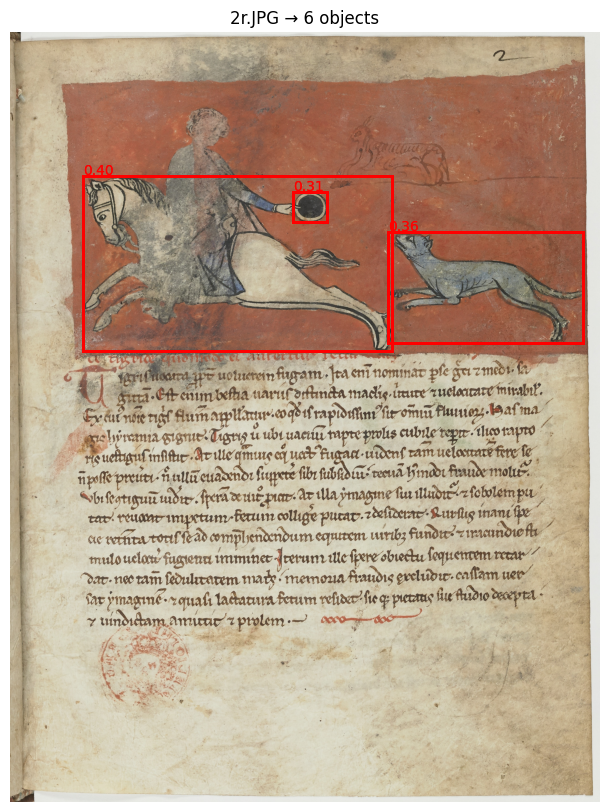

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import cv2
import numpy as np

# წერტილები რამდენი ფოტოს გინდა ვიზუალიზაცია
num_visualize = 5

# წაიშალოს დუბლიკატები ფოტოს მიხედვით
from collections import defaultdict
images_dict = defaultdict(list)
for r in results_all:
    images_dict[r["img_name"]].append(r)

# რამდენიმე ფოტო
for i, (image_name, detections) in enumerate(list(images_dict.items())[:num_visualize]):
    image_path = os.path.join(image_dir, image_name)
    image = cv2.imread(image_path)
    if image is None:
        continue
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    fig, ax = plt.subplots(1, figsize=(10,10))
    ax.imshow(image)

    for det in detections:
        x1, y1, x2, y2 = det["x1"], det["y1"], det["x2"], det["y2"]
        score = det["score"]

        rect = patches.Rectangle(
            (x1, y1),
            x2 - x1,
            y2 - y1,
            linewidth=2,
            edgecolor="red",
            facecolor="none"
        )
        ax.add_patch(rect)
        ax.text(x1, y1-5, f"{score:.2f}", color="red", fontsize=10)

    plt.axis("off")
    plt.title(f"{image_name} → {len(detections)} objects")
    plt.show()

In [ ]:
import pandas as pd

# results_all არის შენი lista dictionary-ებით
df_results = pd.DataFrame(results_all)

# CSV
csv_save_path = "/content/drive/MyDrive/dino_boxes.csv"
df_results.to_csv(csv_save_path, index=False)

print(f"DINO boxes შენახულია CSV-ში: {csv_save_path}")

DINO boxes შენახულია CSV-ში: /content/drive/MyDrive/dino_boxes.csv


SAM

In [ ]:
!pip install git+https://github.com/facebookresearch/segment-anything.git

  Cloning https://github.com/facebookresearch/segment-anything.git to /tmp/pip-req-build-a8k0j_nl
  Running command git clone --filter=blob:none --quiet https://github.com/facebookresearch/segment-anything.git /tmp/pip-req-build-a8k0j_nl
  Resolved https://github.com/facebookresearch/segment-anything.git to commit dca509fe793f601edb92606367a655c15ac00fdf
  Preparing metadata (setup.py) ... done
  Created wheel for segment_anything: filename=segment_anything-1.0-py3-none-any.whl size=36592 sha256=107f5f2f62186f50e60878ee57f36a74604eb2a73a7324c939971f6a2202e627
  Stored in directory: /tmp/pip-ephem-wheel-cache-p9adi9wq/wheels/29/82/ff/04e2be9805a1cb48bec0b85b5a6da6b63f647645750a0e42d4
Successfully built segment_anything


In [ ]:
!wget -O /content/sam_vit_h_4b8939.pth https://dl.fbaipublicfiles.com/segment_anything/sam_vit_h_4b8939.pth

--2026-01-08 16:09:10--  https://dl.fbaipublicfiles.com/segment_anything/sam_vit_h_4b8939.pth
Resolving dl.fbaipublicfiles.com (dl.fbaipublicfiles.com)... 13.35.37.90, 13.35.37.123, 13.35.37.84, ...
Connecting to dl.fbaipublicfiles.com (dl.fbaipublicfiles.com)|13.35.37.90|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 2564550879 (2.4G) [binary/octet-stream]
Saving to: ‘/content/sam_vit_h_4b8939.pth’

/content/sam_vit_h_ 100%[===================>]   2.39G   153MB/s    in 25s     

2026-01-08 16:09:34 (98.5 MB/s) - ‘/content/sam_vit_h_4b8939.pth’ saved [2564550879/2564550879]



In [ ]:
from segment_anything import sam_model_registry, SamPredictor
import torch

sam_checkpoint = "/content/sam_vit_h_4b8939.pth"  # ატვირთე
sam_model = sam_model_registry["vit_h"](checkpoint=sam_checkpoint)
sam_model.to("cuda")
sam_predictor = SamPredictor(sam_model)


In [ ]:
from segment_anything import sam_model_registry, SamPredictor
import cv2
import numpy as np
import torch

In [ ]:
image_path = "/content/drive/MyDrive/E/15v.JPG"
csv_path = "/content/drive/MyDrive/dino_boxes.csv"
sam_checkpoint = "/content/sam_vit_h_4b8939.pth"

In [ ]:
image = cv2.imread(image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

In [ ]:
df = pd.read_csv(csv_path)

rows = df[df["img_name"] == "15v.JPG"]

boxes = []
for _, r in rows.iterrows():
    boxes.append([r["x1"], r["y1"], r["x2"], r["y2"]])

In [ ]:
sam = sam_model_registry["vit_h"](checkpoint=sam_checkpoint)
sam.to("cuda")
sam.eval()

predictor = SamPredictor(sam)
predictor.set_image(image)

In [ ]:
masks = []

for box in boxes:
    box_np = np.array([box], dtype=np.float32)
    mask, _, _ = predictor.predict(
        box=box_np,
        multimask_output=False
    )
    masks.append(mask[0])

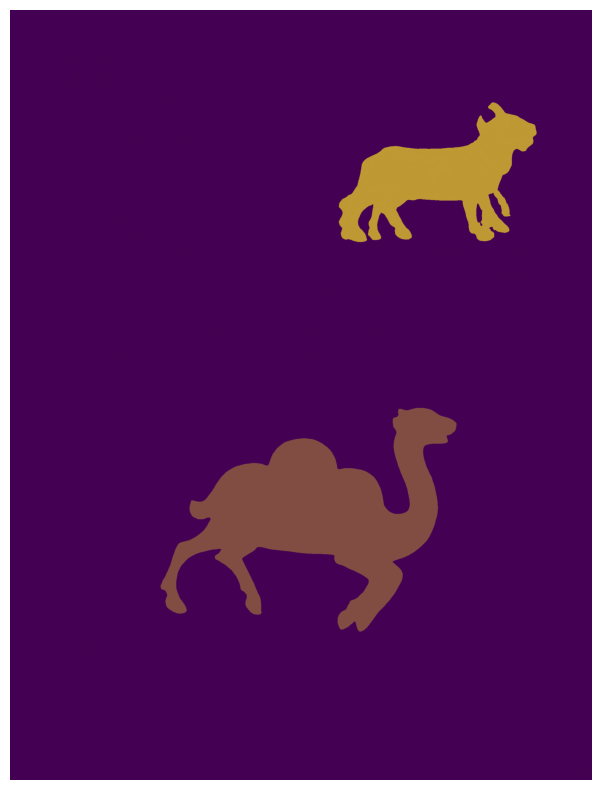

In [ ]:
plt.figure(figsize=(10,10))
plt.imshow(image)

for m in masks:
    plt.imshow(m, alpha=0.5)

plt.axis("off")
plt.show()


In [ ]:
image_path = "/content/drive/MyDrive/E/22r.JPG"
csv_path = "/content/drive/MyDrive/dino_results_boxes.csv"
sam_checkpoint = "/content/sam_vit_h_4b8939.pth"

In [ ]:
image = cv2.imread(image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

In [ ]:
df = pd.read_csv(csv_path)

rows = df[df["img_name"] == "22r.JPG"]

boxes = []
for _, r in rows.iterrows():
    boxes.append([r["x1"], r["y1"], r["x2"], r["y2"]])

In [ ]:
sam = sam_model_registry["vit_h"](checkpoint=sam_checkpoint)
sam.to("cuda")
sam.eval()

predictor = SamPredictor(sam)
predictor.set_image(image)

In [ ]:
masks = []

for box in boxes:
    box_np = np.array([box], dtype=np.float32)
    mask, _, _ = predictor.predict(
        box=box_np,
        multimask_output=False
    )
    masks.append(mask[0])

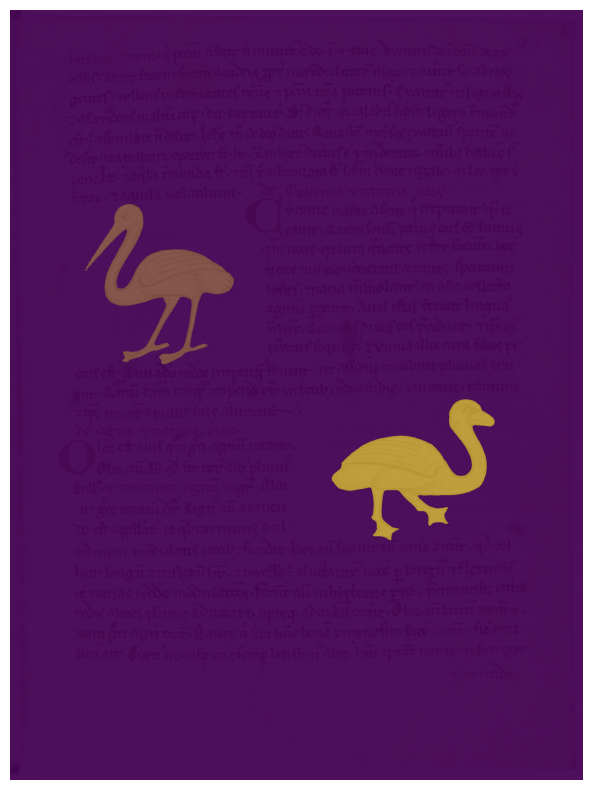

In [ ]:
plt.figure(figsize=(10,10))
plt.imshow(image)

for m in masks:
    plt.imshow(m, alpha=0.5)

plt.axis("off")
plt.show()

In [ ]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from segment_anything import sam_model_registry, SamPredictor
import torch


In [ ]:
# paths
image_dir = "/content/drive/MyDrive/E"          # ყველა ფოტო
csv_path = "/content/drive/MyDrive/dino_boxes.csv"
sam_checkpoint = "/content/sam_vit_h_4b8939.pth"

mask_out_dir = "/content/drive/MyDrive/sam_masks_all"
vis_out_dir  = "/content/drive/MyDrive/sam_vis_all"

os.makedirs(mask_out_dir, exist_ok=True)
os.makedirs(vis_out_dir, exist_ok=True)

# CSV
df = pd.read_csv(csv_path)

# SAM
device = "cuda" if torch.cuda.is_available() else "cpu"
sam = sam_model_registry["vit_h"](checkpoint=sam_checkpoint)
sam.to(device)
sam.eval()

predictor = SamPredictor(sam)


In [ ]:
for image_name in df["img_name"].unique():

    image_path = os.path.join(image_dir, image_name)
    if not os.path.exists(image_path):
        print("not found:", image_name)
        continue

    #  image
    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    predictor.set_image(image)

    #  ბოქსები
    rows = df[df["img_name"] == image_name]

    masks = []
    boxes = []

    for _, r in rows.iterrows():
        box = [r["x1"], r["y1"], r["x2"], r["y2"]]
        box_np = np.array([box], dtype=np.float32)

        mask, _, _ = predictor.predict(
            box=box_np,
            multimask_output=False
        )

        masks.append(mask[0])
        boxes.append(box)

    # save masks
    base = os.path.splitext(image_name)[0]
    for i, mask in enumerate(masks):
        np.save(
            os.path.join(mask_out_dir, f"{base}_mask{i}.npy"),
            mask
        )

    # visualization
    plt.figure(figsize=(10, 10))
    plt.imshow(image)

    for mask in masks:
        plt.imshow(mask, alpha=0.5, cmap="jet")

    plt.axis("off")
    plt.savefig(
        os.path.join(vis_out_dir, f"{base}_sam.png"),
        bbox_inches="tight",
        pad_inches=0,
        dpi=150
    )
    plt.close()

    print(f"{image_name} → {len(masks)} masks")


31v.JPG → 8 masks
25r.JPG → 4 masks
22v.JPG → 12 masks
24v.JPG → 24 masks
2r.JPG → 6 masks
10r.JPG → 8 masks
28r.JPG → 1 masks
7r.JPG → 4 masks
8v.JPG → 8 masks
7v.JPG → 18 masks
12r.JPG → 2 masks
12v.JPG → 4 masks
9v.JPG → 8 masks
15v.JPG → 8 masks
39r.JPG → 7 masks
27v.JPG → 2 masks
32r.JPG → 1 masks
18v.JPG → 24 masks
16v.JPG → 8 masks
15r.JPG → 27 masks
23r.JPG → 1 masks
30v.JPG → 1 masks
14r.JPG → 12 masks
14v.JPG → 12 masks
16r.JPG → 1 masks
2v.JPG → 2 masks
1r.JPG → 1 masks
3v.JPG → 4 masks
8r.JPG → 1 masks
27r.JPG → 8 masks
21v.JPG → 18 masks
11r.JPG → 1 masks
23v.JPG → 8 masks
24r.JPG → 1 masks
28v.JPG → 16 masks
10v.JPG → 2 masks
37r.JPG → 2 masks
20r.JPG → 1 masks
6r.JPG → 8 masks
33v.JPG → 8 masks
29r.JPG → 4 masks
26r.JPG → 27 masks
34r.JPG → 24 masks
34v.JPG → 27 masks
38r.JPG → 2 masks
22r.JPG → 8 masks
36v.JPG → 1 masks
37v.JPG → 2 masks
26v.JPG → 2 masks
4v.JPG → 2 masks
32v.JPG → 1 masks
39v.JPG → 2 masks
18r.JPG → 2 masks
6v.JPG → 1 masks
35r.JPG → 1 masks
33r.JPG → 

In [ ]:
import os
import matplotlib.pyplot as plt

# output folder
vis_out_dir = "/content/drive/MyDrive/sam_vis_all"
os.makedirs(vis_out_dir, exist_ok=True)

# თქვენი loop-ის შიგნით
plt.figure(figsize=(12, 12))  # დიდი figure
plt.imshow(image)

for mask in masks:
    plt.imshow(mask, alpha=0.5, cmap="jet")  # mask overlay

plt.axis("off")

# Save with high dpi and unique name
out_path = os.path.join(vis_out_dir, f"{base}_sam_vis.png")
plt.savefig(out_path, bbox_inches="tight", pad_inches=0, dpi=300)  # 300dpi = good print quality
plt.close()

print(f"{image_name} → {len(masks)} masks saved to {out_path}")


2r.JPG → 4 masks saved to /content/drive/MyDrive/sam_vis_all/4r_sam_vis.png


In [ ]:
import os

vis_dir = "/content/drive/MyDrive/sam_vis_all"

# თუ ყველა ფაილი სურათებია
all_files = os.listdir(vis_dir)
num_images = len(all_files)

print(f"ფოტოების რაოდენობა: {num_images}")


ფოტოების რაოდენობა: 64
